## Load Data

Pada bagian pertama, kita memuat dua file **movies.csv** dan **ratings.csv** ke dalam Python menggunakan pustaka **pandas**. Dataset **movies.csv** berisi informasi tentang film, seperti **movieId** dan judul film, sementara **ratings.csv** berisi informasi tentang **userId**, **movieId**, dan **rating** yang diberikan oleh pengguna. Setelah itu, kita menampilkan beberapa baris pertama dari kedua dataset untuk memastikan bahwa data telah dimuat dengan benar dan kita bisa melihat struktur dasarnya.

In [ ]:
import pandas as pd

# URL untuk dataset movies dan ratings
url_movies = "https://raw.githubusercontent.com/abdlsykr/portfolio/refs/heads/main/Dicoding/Machine_Learning_Terapan/Proyek_Akhir/movies.csv"
url_ratings = "https://raw.githubusercontent.com/abdlsykr/portfolio/refs/heads/main/Dicoding/Machine_Learning_Terapan/Proyek_Akhir/ratings.csv"

# Mengunduh dataset langsung dan memuatnya ke dalam DataFrame
movies = pd.read_csv(url_movies)
ratings = pd.read_csv(url_ratings)

# Menampilkan beberapa baris pertama dari kedua dataset
print("Movies Dataset:")
print(movies.head())

print("\nRatings Dataset:")
print(ratings.head())


Movies Dataset:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings Dataset:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


## Data Understanding

Di sini, kita menggunakan metode **info()** untuk melihat tipe data dan jumlah nilai yang hilang dalam dataset. Ini memberi kita gambaran umum apakah ada kolom yang tidak sesuai jenis datanya atau jika ada data yang hilang yang perlu ditangani.

In [ ]:
# Memeriksa struktur data
print("Movies Dataset Info:")
print(movies.info())

print("\nRatings Dataset Info:")
print(ratings.info())

Movies Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None

Ratings Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


**Movie Dataset:**

*   Dataset ini memiliki 9.742 baris dan 3 kolom.
*   Kolom:
  * movieId: Ini adalah kolom yang berisi ID unik untuk setiap film, dengan total 9.742 entri. Semua nilai dalam kolom ini tidak ada yang hilang, dan tipe data yang digunakan adalah int64.
  * title: Berisi judul film, juga dengan 9.742 entri tanpa nilai yang hilang, dan tipe data object (teks/string).
  * genres: Menyimpan informasi genre film yang dapat terdiri dari lebih dari satu genre yang dipisahkan dengan tanda "pipe" (|). Kolom ini juga berisi 9.742 entri tanpa nilai yang hilang dan bertipe object (teks/string).

**Ratings Dataset:**
*   Dataset ini memiliki 100.836 baris dan 4 kolom.
*   Kolom:
    * userId: Kolom ini berisi ID unik untuk setiap pengguna, ada total 100.836 entri dan semua nilai tidak ada yang hilang. Tipe data yang digunakan adalah int64.
    * movieId: Berisi ID film yang diberikan rating oleh pengguna. Kolom ini memiliki total 100.836 entri dan tipe data int64.
    * rating: Kolom ini berisi nilai rating yang diberikan oleh pengguna pada film tertentu, dengan tipe data float64. Semua nilai tidak ada yang hilang.
    * timestamp: Berisi waktu ketika rating diberikan, dalam format int64 yang merepresentasikan timestamp Unix (waktu dalam detik sejak 1 Januari 1970). Semua nilai juga tidak ada yang hilang.

Dengan menggunakan **describe()**, kita bisa melihat statistik dasar dari setiap kolom numerik di dataset, seperti rata-rata, nilai maksimum, dan standar deviasi. Statistik ini membantu kita memahami rentang data dan apakah ada nilai ekstrem yang perlu diperhatikan.

In [ ]:
# Statistik deskriptif untuk dataset
print("\nMovies Dataset Statistik Deskriptif:")
print(movies.describe())

print("\nRatings Dataset Statistik Deskriptif:")
print(ratings.describe())


Movies Dataset Statistik Deskriptif:
             movieId
count    9742.000000
mean    42200.353623
std     52160.494854
min         1.000000
25%      3248.250000
50%      7300.000000
75%     76232.000000
max    193609.000000

Ratings Dataset Statistik Deskriptif:
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09


### Insight

1.   Dataset ini memiliki sekitar 9.742 film dan 100.836 rating dari pengguna. Artinya, ada banyak film, namun tidak semua film mendapat perhatian yang sama dari pengguna.
2.   Rata-rata rating yang diberikan oleh pengguna adalah 3.5 (dalam skala 1 hingga 5), yang berarti kebanyakan pengguna memberikan rating yang cenderung netral.
3.   Beberapa pengguna hanya memberikan satu rating, sementara pengguna lainnya memberikan lebih dari 600 rating, menunjukkan adanya perbedaan aktivitas pengguna dalam memberikan rating.
4.   Karena banyak film yang memiliki sedikit rating, dataset ini sparse, yang bisa menjadi tantangan bagi model rekomendasi untuk memberikan prediksi yang akurat untuk film yang kurang populer.
5.   Data dikumpulkan antara 2001 hingga 2012, memberikan gambaran bahwa film-film yang lebih tua mungkin memiliki lebih banyak rating dibandingkan film yang lebih baru.





Setelah memeriksa statistik deskriptif, kita memeriksa apakah ada data yang hilang dengan menggunakan **isnull().sum()**. Data yang hilang bisa mempengaruhi kualitas analisis atau model, jadi penting untuk mengetahui dan menangani masalah ini.

In [ ]:
# Mengecek apakah ada nilai yang hilang
print("\nNilai yang hilang pada dataset Movies:")
print(movies.isnull().sum())

print("\nNilai yang hilang pada dataset Ratings:")
print(ratings.isnull().sum())


Nilai yang hilang pada dataset Movies:
movieId    0
title      0
genres     0
dtype: int64

Nilai yang hilang pada dataset Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Pada langkah ini, kita memeriksa apakah ada data yang duplikat. Duplikasi data yang tidak sengaja dapat mengganggu hasil analisis dan harus dihapus.

In [ ]:
# Memeriksa duplikasi pada dataset ratings
print("\nDuplikasi pada Ratings Dataset:")
print(ratings.duplicated().sum())

# Memeriksa duplikasi pada dataset movies
print("\nDuplikasi pada Movies Dataset:")
print(movies.duplicated().sum())


Duplikasi pada Ratings Dataset:
0

Duplikasi pada Movies Dataset:
0


Dengan menggambar grafik distribusi dari kolom **rating**, kita bisa melihat bagaimana rating tersebar di seluruh data. Ini membantu kita memahami apakah sebagian besar pengguna memberikan rating tinggi atau apakah rating tersebar merata.

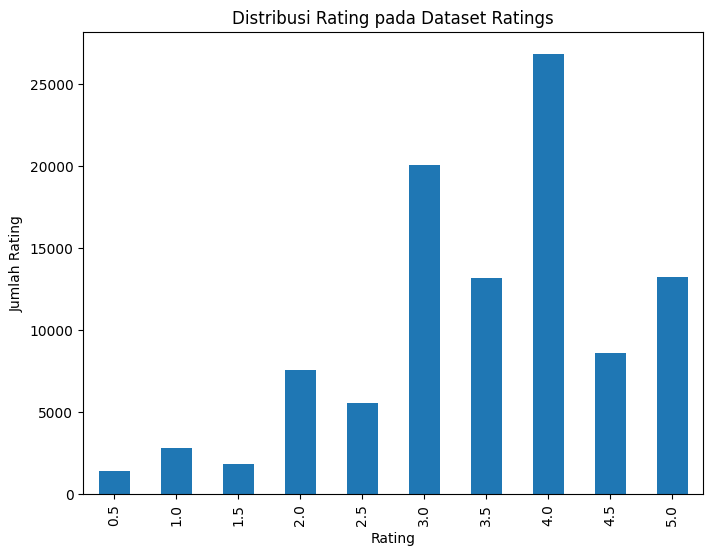

In [ ]:
import matplotlib.pyplot as plt

# Distribusi Rating
plt.figure(figsize=(8, 6))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Rating pada Dataset Ratings')
plt.xlabel('Rating')
plt.ylabel('Jumlah Rating')
plt.show()

### Insight
*   Rating Dominan pada Nilai 3 dan 4: Dari grafik ini, kita dapat melihat bahwa rating 3 memiliki jumlah yang sangat dominan, dengan lebih dari 20.000 rating yang diberikan pada nilai tersebut. Hal ini menunjukkan bahwa sebagian besar pengguna memberikan rating di sekitar nilai tengah (neutral).
*   Rating Tinggi dan Rendah Lebih Sedikit: Rating 1 dan 5 memiliki jumlah yang lebih sedikit, meskipun masih ada beberapa pengguna yang memberikan rating di ekstrim tersebut. Ini menunjukkan bahwa meskipun pengguna lebih cenderung memberikan rating netral (3), masih ada variasi dalam opini pengguna.
*   Distribusi Tidak Merata: Grafik ini menunjukkan bahwa distribusi rating cenderung berpusat di sekitar nilai 3 dan 4, dengan sedikit film yang mendapatkan rating ekstrem (1 atau 5). Ini bisa jadi indikasi bahwa pengguna cenderung memberikan rating yang lebih moderat dan jarang memberikan rating sangat buruk atau sangat baik.






Selanjutnya, kita memeriksa seberapa banyak rating yang diberikan oleh setiap pengguna dan seberapa banyak rating yang diterima oleh setiap film. Ini membantu kita memahami apakah ada pengguna atau film yang hanya sedikit berpartisipasi. Misalnya, jika beberapa pengguna hanya memberikan satu rating, informasi ini mungkin kurang bermanfaat bagi model rekomendasi.


Jumlah Rating per Pengguna:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


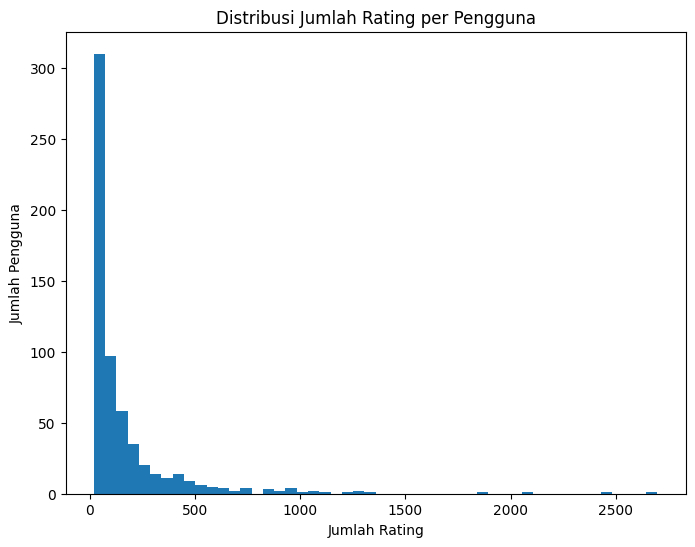

In [ ]:
# Distribusi jumlah rating per pengguna
user_rating_count = ratings.groupby('userId').size()
print("\nJumlah Rating per Pengguna:")
print(user_rating_count.describe())

# Visualisasi distribusi jumlah rating per pengguna
plt.figure(figsize=(8, 6))
user_rating_count.plot(kind='hist', bins=50)
plt.title('Distribusi Jumlah Rating per Pengguna')
plt.xlabel('Jumlah Rating')
plt.ylabel('Jumlah Pengguna')
plt.show()

### Insight



*   Pengguna Aktif vs Pengguna Pasif: Grafik ini menunjukkan bahwa sebagian besar pengguna memberikan sedikit rating, sementara ada sejumlah kecil pengguna yang sangat aktif, memberikan lebih dari 300 rating. Hal ini menandakan bahwa distribusi jumlah rating sangat tidak merata.
*   Mayoritas Pengguna Memberikan Sedikit Rating: Sebagian besar pengguna hanya memberikan beberapa rating, sedangkan sebagian kecil memberikan banyak rating. Ini menunjukkan bahwa banyak pengguna lebih pasif dalam memberikan rating, sedangkan beberapa pengguna sangat aktif.
*   Sparsity Data: Kondisi ini juga berkontribusi pada sparsity (kekosongan) dalam dataset, di mana banyak film yang tidak mendapat cukup banyak rating, yang bisa menjadi tantangan dalam membangun sistem rekomendasi yang efektif.







Jumlah Rating per Film:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


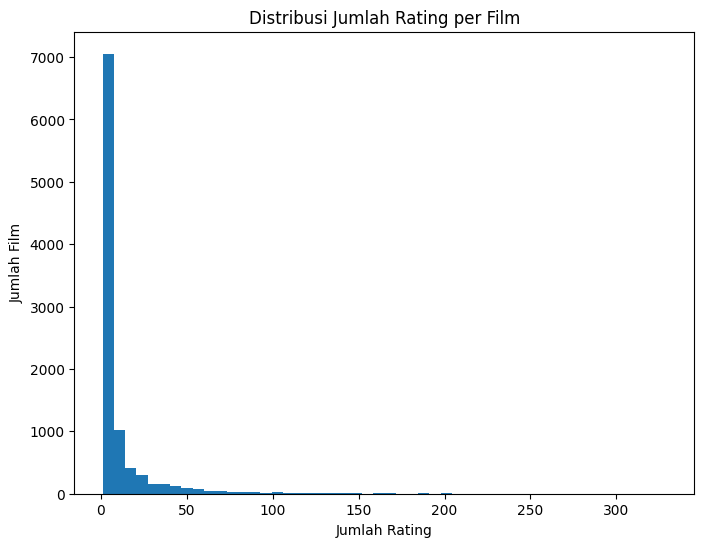

In [ ]:
# Distribusi jumlah rating per film
movie_rating_count = ratings.groupby('movieId').size()
print("\nJumlah Rating per Film:")
print(movie_rating_count.describe())

# Visualisasi distribusi jumlah rating per film
plt.figure(figsize=(8, 6))
movie_rating_count.plot(kind='hist', bins=50)
plt.title('Distribusi Jumlah Rating per Film')
plt.xlabel('Jumlah Rating')
plt.ylabel('Jumlah Film')
plt.show()

### Insight

*   Sebagian besar film memiliki sedikit rating: Grafik menunjukkan bahwa sebagian besar film mendapatkan sangat sedikit rating, dengan sebagian besar nilai terkonsentrasi di sekitar 0 hingga 10 rating. Artinya, banyak film yang tidak mendapatkan perhatian banyak dari pengguna.
*   Sedikit film mendapatkan banyak rating: Ada beberapa film yang mendapatkan banyak rating, namun jumlahnya jauh lebih sedikit dibandingkan dengan film yang memiliki sedikit rating. Sebagian kecil film mendapatkan lebih dari 100 rating, dan jumlah film dengan rating tinggi ini jauh lebih sedikit.
*   Distribusi sangat miring ke kiri: Grafik ini menunjukkan distribusi yang sangat miring ke kiri, yang berarti banyak film hanya mendapatkan sedikit rating. Hal ini dapat menyebabkan sparsity dalam data yang harus dihadapi saat membangun model rekomendasi.





Jika dataset **movies.csv** mengandung informasi genre film, kita juga melihat sebaran genre yang paling sering muncul. Ini memberi wawasan tambahan tentang jenis film yang dominan dalam dataset dan apakah genre tertentu lebih banyak mendapatkan perhatian dari pengguna.


Distribusi Genre Film:
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64


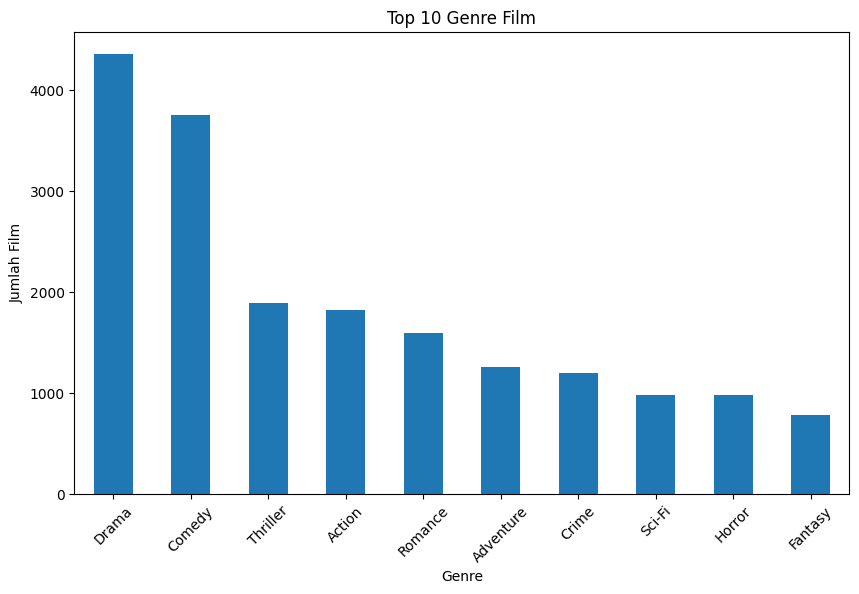

In [ ]:
# Memeriksa distribusi genre film
if 'genres' in movies.columns:
    genre_distribution = movies['genres'].str.split('|', expand=True).stack().value_counts()
    print("\nDistribusi Genre Film:")
    print(genre_distribution)

    # Visualisasi distribusi genre
    plt.figure(figsize=(10, 6))
    genre_distribution.head(10).plot(kind='bar')
    plt.title('Top 10 Genre Film')
    plt.xlabel('Genre')
    plt.ylabel('Jumlah Film')
    plt.xticks(rotation=45)
    plt.show()


### Insight



1.   Drama mendominasi dengan lebih dari 4.000 film, diikuti Komedi dan Thriller yang juga cukup banyak.
2.   Aksi dan Romansa lebih sedikit, namun tetap populer.
3.   Genre seperti Sci-Fi, Horror, dan Fantasy memiliki jumlah yang lebih sedikit, menunjukkan audiens yang lebih spesifik.
4.   Dokumenter dan Perang termasuk yang paling sedikit, mencerminkan daya tarik komersial yang lebih rendah.



## Data Preprocessing

Kita memeriksa apakah ada **movieId** dalam **ratings.csv** yang tidak ada di **movies.csv**. Jika ada, ini menunjukkan bahwa ada rating yang tidak valid karena merujuk pada film yang tidak tercatat. Ini perlu diperbaiki dengan menghapus data tersebut.

In [ ]:
# Memeriksa apakah ada movieId yang tidak ada dalam movies.csv
invalid_movie_ids = ratings[~ratings['movieId'].isin(movies['movieId'])]
print(f"Jumlah movieId yang tidak ada dalam movies.csv: {invalid_movie_ids.shape[0]}")

# Menampilkan beberapa movieId yang tidak valid
print(invalid_movie_ids.head())

Jumlah movieId yang tidak ada dalam movies.csv: 0
Empty DataFrame
Columns: [userId, movieId, rating, timestamp]
Index: []


Beberapa pengguna mungkin hanya memberikan satu rating atau sangat sedikit rating. Hal ini bisa menjadi masalah karena model rekomendasi bergantung pada interaksi pengguna dengan berbagai item (film). Pengguna dengan sedikit interaksi tidak memberikan cukup informasi untuk membangun model rekomendasi yang baik. Oleh karena itu, kita memeriksa pengguna dengan sedikit rating dan mempertimbangkan untuk menghapus mereka dari dataset.

In [ ]:
# Memeriksa pengguna dengan hanya satu rating
user_rating_count = ratings.groupby('userId').size()
users_with_one_rating = user_rating_count[user_rating_count == 1]
print(f"Jumlah pengguna dengan hanya satu rating: {users_with_one_rating.shape[0]}")

# Menampilkan beberapa pengguna dengan satu rating
print(users_with_one_rating.head())


Jumlah pengguna dengan hanya satu rating: 0
Series([], dtype: int64)


Kita juga memeriksa apakah ada timestamp yang tidak realistis, seperti timestamp yang sangat kecil atau besar, yang mungkin menunjukkan adanya kesalahan dalam pencatatan waktu. Dengan memeriksa rentang timestamp, kita dapat memastikan bahwa data yang digunakan sesuai dengan rentang waktu yang diharapkan.

In [ ]:
import datetime

# Fungsi untuk mengonversi timestamp ke datetime
def convert_timestamp(timestamp):
    return datetime.datetime.fromtimestamp(timestamp)

# Memeriksa outlier pada kolom timestamp
timestamp_min = ratings['timestamp'].min()
timestamp_max = ratings['timestamp'].max()

# Mengonversi timestamp ke format tanggal
min_date = convert_timestamp(timestamp_min)
max_date = convert_timestamp(timestamp_max)

# Menghitung rentang waktu untuk melihat apakah ada timestamp yang tidak realistis
print(f"Rentang Timestamp: Min = {timestamp_min}, Max = {timestamp_max}")
print(f"Min Timestamp (Converted to Date): {min_date}")
print(f"Max Timestamp (Converted to Date): {max_date}")


Rentang Timestamp: Min = 828124615, Max = 1537799250
Min Timestamp (Converted to Date): 1996-03-29 18:36:55
Max Timestamp (Converted to Date): 2018-09-24 14:27:30


Beberapa film mungkin hanya mendapatkan sedikit rating, yang bisa berarti film tersebut tidak cukup populer atau memiliki terlalu sedikit informasi. Memeriksa film dengan sedikit rating membantu kita memutuskan apakah kita perlu menghapus film tersebut dari dataset untuk memastikan model tidak terpengaruh oleh data yang tidak representatif.

In [ ]:
# Memeriksa film dengan sedikit rating
movie_rating_count = ratings.groupby('movieId').size()
movies_with_few_ratings = movie_rating_count[movie_rating_count < 5]  # Misalnya film yang memiliki kurang dari 5 rating
print(f"Jumlah film dengan kurang dari 5 rating: {movies_with_few_ratings.shape[0]}")

# Menampilkan beberapa film dengan sedikit rating
print(movies_with_few_ratings.head())


Jumlah film dengan kurang dari 5 rating: 6074
movieId
30    3
38    4
40    2
49    1
53    2
dtype: int64


Setelah memeriksa data lebih lanjut, kita melakukan beberapa langkah pembersihan data. Salah satunya adalah menghapus **duplikasi** yang ada pada dataset **ratings.csv** dan memastikan tidak ada pengguna yang memberikan rating ganda untuk film yang sama.

In [ ]:
# Menghapus duplikasi pada ratings
ratings = ratings.drop_duplicates(subset=['userId', 'movieId'])


Kita juga mengisi nilai yang hilang (misalnya, jika ada rating yang hilang) dengan rata-rata rating. Ini membantu menjaga konsistensi data dan memastikan bahwa model tidak terpengaruh oleh data yang hilang.

In [ ]:
# Mengisi nilai yang hilang pada ratings dengan rata-rata rating
ratings['rating'].fillna(ratings['rating'].mean(), inplace=True)


<ipython-input-19-72fec4344f73>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ratings['rating'].fillna(ratings['rating'].mean(), inplace=True)


Selanjutnya, kita membuat **matriks pengguna x film**, yang berisi rating yang diberikan oleh setiap pengguna untuk setiap film. Matriks ini penting untuk model rekomendasi, karena akan menjadi input utama bagi model **Neural Collaborative Filtering**

In [ ]:
# Membuat matriks pengguna x film
ratings_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Menampilkan matriks pertama
print(ratings_matrix.head())

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0

Pada bagian ini, kita mempersiapkan data agar dapat digunakan oleh model deep learning. userId dan movieId yang ada dalam dataset kita ubah menjadi angka numerik, yang mempermudah model dalam memproses data. Setiap pengguna dan film diberikan **indeks numerik** menggunakan pemetaan atau **mapping**. Selanjutnya, kita menambahkan kolom baru dalam dataset yang berisi indeks numerik untuk **userId** dan **movieId**.

In [ ]:
# Mengubah userId dan movieId menjadi indeks
user_mapping = {user: index for index, user in enumerate(ratings['userId'].unique())}
movie_mapping = {movie: index for index, movie in enumerate(ratings['movieId'].unique())}

# Menambahkan kolom user_index dan movie_index ke dataset
ratings['user_index'] = ratings['userId'].map(user_mapping)
ratings['movie_index'] = ratings['movieId'].map(movie_mapping)

# Menampilkan beberapa baris dari dataset yang telah diproses
print(ratings.head())


   userId  movieId  rating  timestamp  user_index  movie_index
0       1        1     4.0  964982703           0            0
1       1        3     4.0  964981247           0            1
2       1        6     4.0  964982224           0            2
3       1       47     5.0  964983815           0            3
4       1       50     5.0  964982931           0            4


Membagi data dengan pembagian 80:20 untuk data training dan testing

In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi training dan testing
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")


Training data shape: (80668, 6)
Testing data shape: (20168, 6)


## Model Development Neural Collaborative Filtering (NCF)

Setelah data siap, kita membangun model **Neural Collaborative Filtering (NCF)**, yang digunakan untuk memprediksi rating antara pengguna dan film. Model ini memanfaatkan **embedding layers** yang mengubah ID pengguna dan film menjadi vektor berdimensi rendah, yang memudahkan model untuk mempelajari hubungan antara pengguna dan film. Vektor-vektor ini digabungkan dan diproses oleh beberapa lapisan jaringan saraf untuk menghasilkan rating yang diprediksi untuk setiap kombinasi pengguna dan film.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Dimensi input
num_users = len(user_mapping)
num_movies = len(movie_mapping)
embedding_dim = 50  # Dimensi embedding

# Membangun model
user_input = layers.Input(shape=(1,), dtype=tf.int32, name='user')
movie_input = layers.Input(shape=(1,), dtype=tf.int32, name='movie')

# Embedding layer untuk user dan movie
user_embedding = layers.Embedding(num_users, embedding_dim)(user_input)
movie_embedding = layers.Embedding(num_movies, embedding_dim)(movie_input)

# Flatten embeddings
user_embedding = layers.Flatten()(user_embedding)
movie_embedding = layers.Flatten()(movie_embedding)

# Concatenate embeddings
concatenated = layers.concatenate([user_embedding, movie_embedding])

# Fully connected layers
x = layers.Dense(128, activation='relu')(concatenated)
x = layers.Dense(64, activation='relu')(x)

# Output layer (rating prediksi)
output = layers.Dense(1, activation='linear')(x)

# Model NCF
model = models.Model(inputs=[user_input, movie_input], outputs=output)

# Menyusun model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     30,500 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    486,200 │ movie[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 537,949 (2.05 MB)

 Trainable params: 537,949 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Setelah model dibangun, kita melatihnya menggunakan data **training**. Pada tahap ini, model belajar dari data yang sudah ada untuk memprediksi rating yang belum diberikan oleh pengguna. Proses ini dilakukan dalam beberapa **epoch** (iterasi), dan pada setiap iterasi, model mencoba memperbaiki prediksi ratingnya agar semakin mendekati rating yang sebenarnya. Selama pelatihan, kita juga memantau kinerja model pada **data uji** yang tidak digunakan dalam pelatihan.

In [ ]:
# Melatih model
history = model.fit(
    [train_data['user_index'], train_data['movie_index']], train_data['rating'],
    epochs=20, batch_size=64, validation_data=([test_data['user_index'], test_data['movie_index']], test_data['rating'])
)


Epoch 1/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 2.2495 - val_loss: 0.8054
Epoch 2/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6912 - val_loss: 0.7969
Epoch 3/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6389 - val_loss: 0.7668
Epoch 4/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.5836 - val_loss: 0.7724
Epoch 5/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.5181 - val_loss: 0.7996
Epoch 6/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.4363 - val_loss: 0.8232
Epoch 7/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.3716 - val_loss: 0.8460
Epoch 8/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3209 - val_loss: 0.8683
Epoch 9/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.2822 - val_loss: 0.8930
Epoch 10/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.2498 - val_loss: 0.9094
Epoch 11/20
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2213 - val_loss: 0.9204
Epoch 12/20
1261/1261 ━━━━━

Setelah model selesai dilatih, kita mengevaluasi kinerjanya dengan menghitung **RMSE (Root Mean Squared Error)**, yang mengukur seberapa baik model memprediksi rating dibandingkan dengan rating yang sebenarnya.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Prediksi rating untuk data uji
predictions = model.predict([test_data['user_index'], test_data['movie_index']])

# Menghitung RMSE
rmse = np.sqrt(mean_squared_error(test_data['rating'], predictions))
print(f"RMSE: {rmse}")


631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
RMSE: 0.9929762282705991


#### Insight
RMSE 0.99 adalah nilai yang cukup baik untuk model rekomendasi

Dengan model yang telah dilatih, kita dapat menggunakannya untuk memberikan **rekomendasi film** kepada pengguna. Fungsi ini memprediksi rating untuk semua film yang ada, lalu memilih film dengan rating tertinggi yang kemungkinan besar akan disukai oleh pengguna. Film-film ini kemudian disarankan kepada pengguna berdasarkan prediksi model.

In [ ]:
def recommend_movies(user_id, top_n=5):
    # Menentukan indeks pengguna
    user_idx = user_mapping[user_id]

    # Membuat prediksi untuk seluruh film
    movie_indices = np.array([i for i in range(num_movies)])
    user_input_array = np.full_like(movie_indices, user_idx)  # Sama untuk semua film

    # Reshape input arrays to match model's expected input shape (batch_size, 1)
    user_input_reshaped = user_input_array.reshape(-1, 1)
    movie_indices_reshaped = movie_indices.reshape(-1, 1)

    # Melakukan prediksi
    predicted_ratings = model.predict([user_input_reshaped, movie_indices_reshaped])

    # Menampilkan top N film berdasarkan prediksi rating tertinggi
    top_movie_indices = predicted_ratings.flatten().argsort()[-top_n:][::-1]

    print(f"Top {top_n} movie recommendations for User {user_id}:")
    for idx in top_movie_indices:
        # Get the original movie ID from the movie index
        original_movie_id = list(movie_mapping.keys())[list(movie_mapping.values()).index(idx)]
        movie_title = movies[movies['movieId'] == original_movie_id]['title'].values[0]
        predicted_rating = predicted_ratings.flatten()[idx]
        print(f"Movie: {movie_title}, Predicted Rating: {predicted_rating:.2f}")

# Memberikan rekomendasi untuk pengguna dengan ID 1
recommend_movies(user_id=1)


304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Top 5 movie recommendations for User 1:
Movie: The Salt of the Earth (2014), Predicted Rating: 5.81
Movie: A Plasticine Crow (1981), Predicted Rating: 5.63
Movie: Easy A (2010), Predicted Rating: 5.59
Movie: 25th Hour (2002), Predicted Rating: 5.59
Movie: Kids (1995), Predicted Rating: 5.57
